<a href="https://colab.research.google.com/github/selemansolar-ai/Unshakable_Energy_AI/blob/main/feature_importance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# DATA YA SOLAR HALISI
np.random.seed(42)
saa= np.tile(range( 6,19),7)
mwangaza= np.maximum(0,1000*np.sin((saa-6)/13*np.pi)) + np.random.rand(91)*100 #  Jua linapanda na kushuka
mawingu=np.random.rand(91)*100
joto=22+mwangaza/50  + np.random.rand(91)*3 #joto linapanda qna jua
saa_norm=saa

# FORMULA YA SOLAR
Power_W=(mwangaza*0.08)-(mawingu*0.2)+np.random.rand(91)*5
Power_W=np.maximum(0, Power_W)

df_halisi=pd.DataFrame({'saa':saa, 'joto_c':joto, 'mwangaza':mwangaza, 'mawingu_%':mawingu, 'Power_W':Power_W})

df_halisi.to_csv('data_ya_solar.csv', index= False)

print("---DATA YA SOLAR HALISI---")
print(df_halisi.head())

# GAWANYA ,FUNDISHA NA PIMA
x=df_halisi[['saa', 'joto_c', 'mwangaza', 'mawingu_%']]
y=df_halisi['Power_W']
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)

model=DecisionTreeRegressor(max_depth=5,random_state=42)
model.fit(x_train, y_train)
y_pred=model.predict(x_test)

r2=r2_score(y_test, y_pred)
print(f"\n---MATOKEO YA AI KWA DATA HALISI---")
print(f"Usahihi R2 score: {r2:.2f}")

# TUIJARIBU AI YETU KWA SIKU MPYA
data_mpya=pd.DataFrame({
    'saa':[9,12,15],
    'joto_c':[28,33,31],
    'mwangaza':[400,950,600],# Asubuhi,mchana,jioni
    'mawingu_%':[40,5,20]
})


Utabiri=model.predict(data_mpya)

print("---UTABIRI WA AI KWA KESHO---")
for i, p in enumerate(Utabiri):
  print(f"saa {data_mpya['saa'][i]}: Mwangaza {data_mpya['mwangaza'][i]}-> inatabiri Power= {p:.1}W")

---DATA YA SOLAR HALISI---
   saa     joto_c    mwangaza  mawingu_%    Power_W
0    6  25.523161   37.454012  71.324479   0.000000
1    7  31.319760  334.387095  76.078505  14.091979
2    8  33.532276  537.922566  56.127720  34.315843
3    9  38.439722  722.988507  77.096718  46.411213
4   10  41.223381  838.585730  49.379560  60.460766

---MATOKEO YA AI KWA DATA HALISI---
Usahihi R2 score: 0.98
---UTABIRI WA AI KWA KESHO---
saa 9: Mwangaza 400-> inatabiri Power= 2e+01W
saa 12: Mwangaza 950-> inatabiri Power= 8e+01W
saa 15: Mwangaza 600-> inatabiri Power= 2e+01W


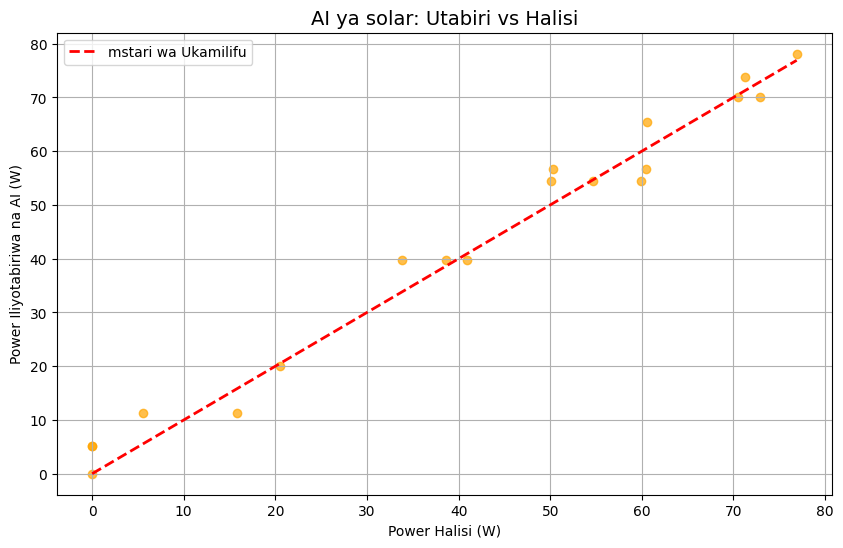


---RIPOTI YA MWISHO---
Ikiwa dots zote ziko karibu na mstari mekundu = AI ni mwerevu
R2 score yetu: 0.98=98% usahili


In [42]:
import matplotlib.pyplot as plt

# 1.PATA UTABIRI WA DATA YOTE YA TEST
y_pred=model.predict(x_test)

# TENGENEZA GRAPH "KWELI VS UTABIRI"
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.7, color='orange')

# Mstari wa ukamilifu - ikiwa AI ni 100% sahihi data zote zitakuwa hapa
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--', lw=2, label='mstari wa Ukamilifu')

plt.title('AI ya solar: Utabiri vs Halisi', fontsize=14)
plt.xlabel('Power Halisi (W)')
plt.ylabel('Power Iliyotabiriwa na AI (W)')
plt.legend()
plt.grid(True)
plt.show()

print("\n---RIPOTI YA MWISHO---")
print(f"Ikiwa dots zote ziko karibu na mstari mekundu = AI ni mwerevu")
print(f"R2 score yetu: {r2:.2f}=98% usahili")

In [44]:
import joblib
# Hifadhi model
joblib.dump(model, 'ai_ya_solar.pkl')
print("✅ Model imehifadhiwa kama 'ai_ya_solar.pkl'")

# Jaribu kuitolea upesi
model_iliyohifadhiwa=joblib.load('ai_ya_solar.pkl')
utabiri_haraka=model_iliyohifadhiwa.predict([[12,33,950,5]])# saa12, joto33, mwangaza950, mawingu5
print(f"Utabiri wa haraka saa 12: {utabiri_haraka[0]:.1f} W")

✅ Model imehifadhiwa kama 'ai_ya_solar.pkl'
Utabiri wa haraka saa 12: 78.1 W


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [45]:
from sklearn.ensemble import RandomForestRegressor

print("\n---TUNAFUNDISHA RANDOM FOREST SASA---")

# Fundisha Random Forest- miti 100 inapiga kura
rf_model=RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(x_train, y_train)

# Pima
y_pred_rf=rf_model.predict(x_test)
r2_rf=r2_score(y_test,y_pred_rf)

print(f"R2 score ya Decision Tree: {r2:.2f}")
print(f"R2 score ya Random Forest: {r2_rf:.3f}")

if r2_rf>r2:
  print("🔥 RANDOM FOREST AMESHINDA!")
else:
  print("💪 DECISION TREE BADO NI BOSS!")


---TUNAFUNDISHA RANDOM FOREST SASA---
R2 score ya Decision Tree: 0.98
R2 score ya Random Forest: 0.985
🔥 RANDOM FOREST AMESHINDA!


In [46]:
import pandas as pd
import joblib

# SOMA AI YA KWELI KUTOKA SENSOR
# Badili 'data_ya_solar.csv' na jina la file
df_halisi=pd.read_csv('data_ya_solar.csv')

print("---DATA YA KWELI KUTOKA SENSOR---")
print(df_halisi.head())

# TUMIA AI TILIYOIHIFADHI KUTABIRI
model_iliyohifadhiwa=joblib.load('ai_ya_solar.pkl')

X_mpya=df_halisi[['saa', 'joto_c', 'mwangaza', 'mawingu_%']]
utabiri_halisi=model_iliyohifadhiwa.predict(X_mpya)

df_halisi['Power_utabiri_W']= utabiri_halisi

print("\n---UTABIRI WA AI KWA DATA HALISI---")
print("df_halisi[['saa', 'mwangaza, 'Power_W', 'Power_utabiri_W']].head()")

---DATA YA KWELI KUTOKA SENSOR---
   saa     joto_c    mwangaza  mawingu_%    Power_W
0    6  25.523161   37.454012  71.324479   0.000000
1    7  31.319760  334.387095  76.078505  14.091979
2    8  33.532276  537.922566  56.127720  34.315843
3    9  38.439722  722.988507  77.096718  46.411213
4   10  41.223381  838.585730  49.379560  60.460766

---UTABIRI WA AI KWA DATA HALISI---
df_halisi[['saa', 'mwangaza, 'Power_W', 'Power_utabiri_W']].head()


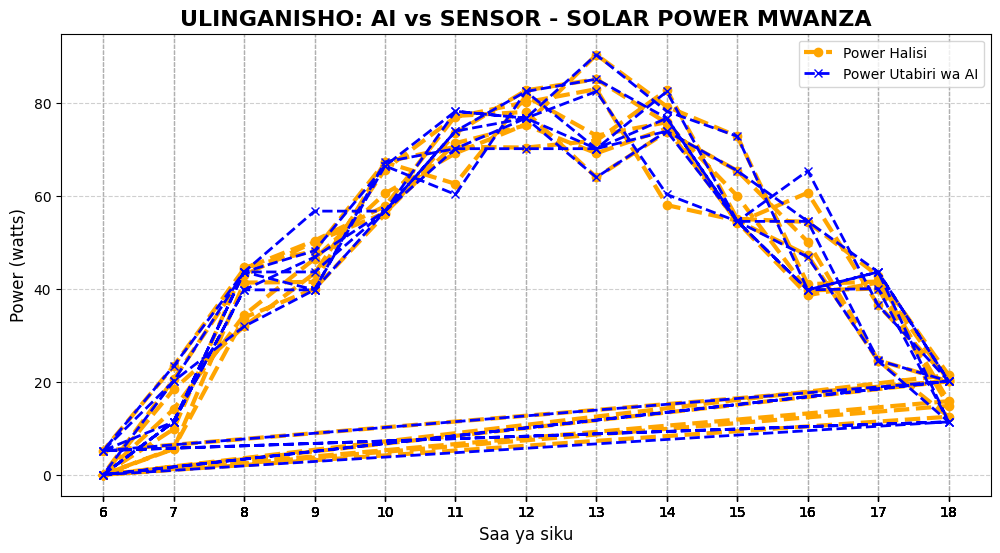

✅ GRAPH IMETENGENEZWA!


In [14]:
import matplotlib.pyplot as plt

# 1.CHORA GRAPH YA ULINGANISHO
plt.figure(figsize=(12,6))#fanya iwe kubwa

# Mstari wa 1:'Power Halisi ' kutoka sensor
plt.plot(df_halisi['saa'], df_halisi['Power_W'],
         label='Power Halisi',
         marker='o',
         color='orange',
         linestyle='--',
         linewidth=3)

# Mstari wa 2: Power  Utabiri kutoka AI - BLUE DOTTED
plt.plot(df_halisi['saa'], df_halisi['Power_utabiri_W'],
         label='Power Utabiri wa AI',
         marker='x',
         color='blue',
         linewidth=2,
         linestyle='--')

# 2 WEKA TITLE NA LABELS
plt.title('ULINGANISHO: AI vs SENSOR - SOLAR POWER MWANZA',fontsize=16,fontweight='bold')
plt.xlabel('Saa ya siku', fontsize=12)
plt.ylabel('Power (watts)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(df_halisi['saa']) #Onyesha saa zote
plt.show()

print('✅ GRAPH IMETENGENEZWA!')

Index(['saa', 'joto_c', 'mwangaza', 'mawingu_%', 'Power_W'], dtype='object')


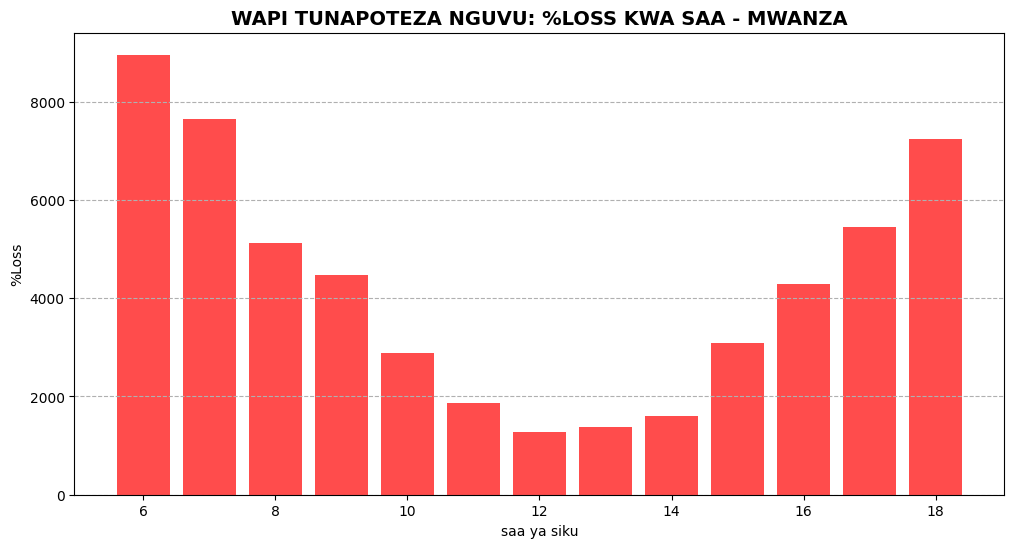

In [47]:
import matplotlib.pyplot as plt

# 1.Fungua data
df=pd.read_csv('data_ya_solar.csv')
print(df.columns)

# 2. Hesabu %LOSS
power_max=df['Power_W'].max()
df['Loss_Percent']=((power_max - df['Power_W'])*100)

# 3.Panga kwa saa
df['Hour']=df['saa']
loss_by_hour=df.groupby('Hour')['Loss_Percent'].mean()

# 4.Chora Graph
plt.figure(figsize=(12,6))
plt.bar(loss_by_hour.index, loss_by_hour.values, color='red', alpha=0.7)
plt.title('WAPI TUNAPOTEZA NGUVU: %LOSS KWA SAA - MWANZA',fontsize=14, fontweight='bold')
plt.xlabel('saa ya siku')
plt.ylabel('%Loss')
plt.grid(axis='y', linestyle='--')
plt.savefig('loss_graph.png')
plt.show()

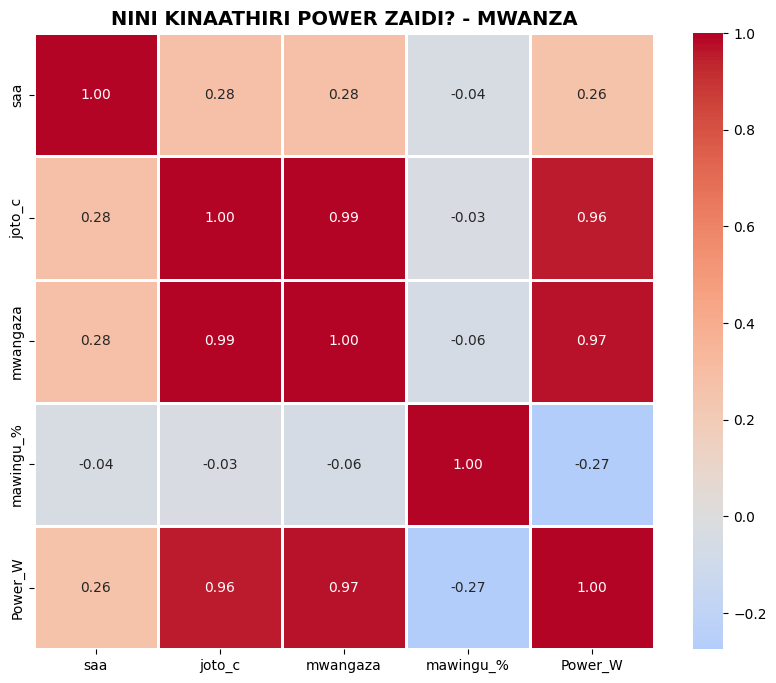

In [54]:
import seaborn as sns
import pandas as np
import matplotlib.pyplot as plt
# 1.CORRELATION HEATMAP

plt.figure(figsize=(10,8))
corr=df[['saa', 'joto_c', 'mwangaza', 'mawingu_%', 'Power_W']].corr()
sns.heatmap(corr, annot=True,cmap='coolwarm', center=0,fmt=".2f",linewidths=1)
plt.title('NINI KINAATHIRI POWER ZAIDI? - MWANZA',fontsize=14,fontweight='bold')

plt.savefig('heatmap.png')
plt.show()





AI INASEMA NINI MUHIMU ZAIDI
     Feature  Importance
2   mwangaza    0.788501
1     joto_c    0.182201
3  mawingu_%    0.029106
0        saa    0.000192


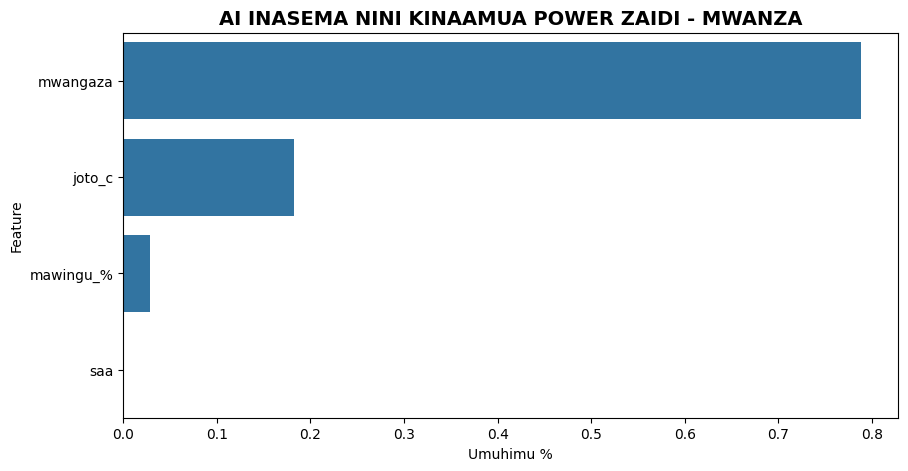

In [60]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1.Features Importance
importances=model.feature_importances_
features=['saa','joto_c','mwangaza','mawingu_%']

# 2.Panga kutoka kubwa kwenda ndogo
feature_importance_df=pd.DataFrame({
    'Feature':features,
    'Importance':importances
}).sort_values('Importance', ascending=False)

print("AI INASEMA NINI MUHIMU ZAIDI")
print(feature_importance_df)

# 3.Chora graph
plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt. title('AI INASEMA NINI KINAAMUA POWER ZAIDI - MWANZA',fontsize=14, fontweight='bold')
plt.xlabel('Umuhimu %')
plt.savefig('feature_importance.png')
plt.show()
